## MNIST 数据探索 — 认识你的数据

在训练任何模型之前，首先要**理解数据长什么样**。

### 什么是 MNIST？

MNIST 是深度学习领域的「Hello World」—— 一个手写数字识别数据集：
- **70,000 张** 28×28 像素的灰度手写数字图片
- **10 个类别**：数字 0~9
- **训练集 60,000 张** + **测试集 10,000 张**

### 本 Notebook 做什么？

1. 从 OpenML 自动下载 MNIST 数据集
2. 可视化样本图片，直观感受数据
3. 分析类别分布，检查数据是否均衡
4. 转为 PyTorch Tensor 并构建 DataLoader

> 运行完这个 notebook 后，你会对 MNIST 有一个直观的认识，为后续训练做好准备。

## 1. 导入依赖

只需要 numpy（数值计算）、matplotlib/seaborn（可视化）、sklearn（加载数据）、PIL（图片处理）。

In [6]:
# [1. 导入依赖]
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# ==== 中文字体配置 ====
# matplotlib 默认不支持中文，需手动指定支持中文的字体
# 优先级：微软雅黑 > 黑体 > DejaVu Sans（英文回退）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 防止负号显示为方块

# Jupyter 魔法命令：图表直接嵌入 notebook，retina 高清渲染
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

print('依赖导入完成！')

依赖导入完成！


## 2. 加载 MNIST 数据集

使用 `fetch_openml` 从 OpenML 自动下载。首次运行会联网下载（约 11MB），之后从缓存读取。

### 数据格式

```
原始数据: (70000, 784) — 每行是一张 28×28 图片展平的 784 维向量
    ↓ reshape
恢复形状: (70000, 28, 28) — 恢复为二维图像矩阵
    ↓ 划分
训练集: (60000, 28, 28)  +  测试集: (10000, 28, 28)
```

> **注意**：MNIST 的标签是字符串类型，需要转为 `uint8` 整数。

In [2]:
# [2. 加载 MNIST 数据]
# fetch_openml 从 OpenML 下载 | 缓存到 ../data | 70K×784 → 28×28 矩阵 | 前60K训练 + 后10K测试
mnist = fetch_openml(
    name="mnist_784",
    version=1,
    as_frame=False,
    cache=True,
    data_home="../data"               # 下载文件缓存到项目 data 目录
)
print(f"原始形状: {mnist.data.shape}")  # (70000, 784)
print(f"标签类型: {mnist.target.dtype}")  # 字符串，需转换

# 将 784 维向量恢复为 28×28 矩阵，标签转为 uint8 整数
X = mnist.data.reshape(-1, 28, 28).astype(np.uint8)
y = mnist.target.astype(np.uint8)

# 标准 60K / 10K 划分
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print(f"\n训练集: {len(X_train)} 样本")
print(f"测试集: {len(X_test)} 样本")
print(f"图片尺寸: {X_train.shape[1]}×{X_train.shape[2]}")
print(f"像素值范围: [{X_train.min()}, {X_train.max()}] (0=黑色, 255=白色)")

原始形状: (70000, 784)
标签类型: object

训练集: 60000 样本
测试集: 10000 样本
图片尺寸: 28×28
像素值范围: [0, 255] (0=黑色, 255=白色)


## 3. 数据可视化：看看样本长什么样

随机抽取 25 张训练集图片，感受一下 MNIST 手写数字的多样性。

### 你会看到什么？

- 同一个人写的不同数字风格一致
- 不同人写的同一个数字差别很大
- 有些数字连人都难以辨认（这也是模型的难点）

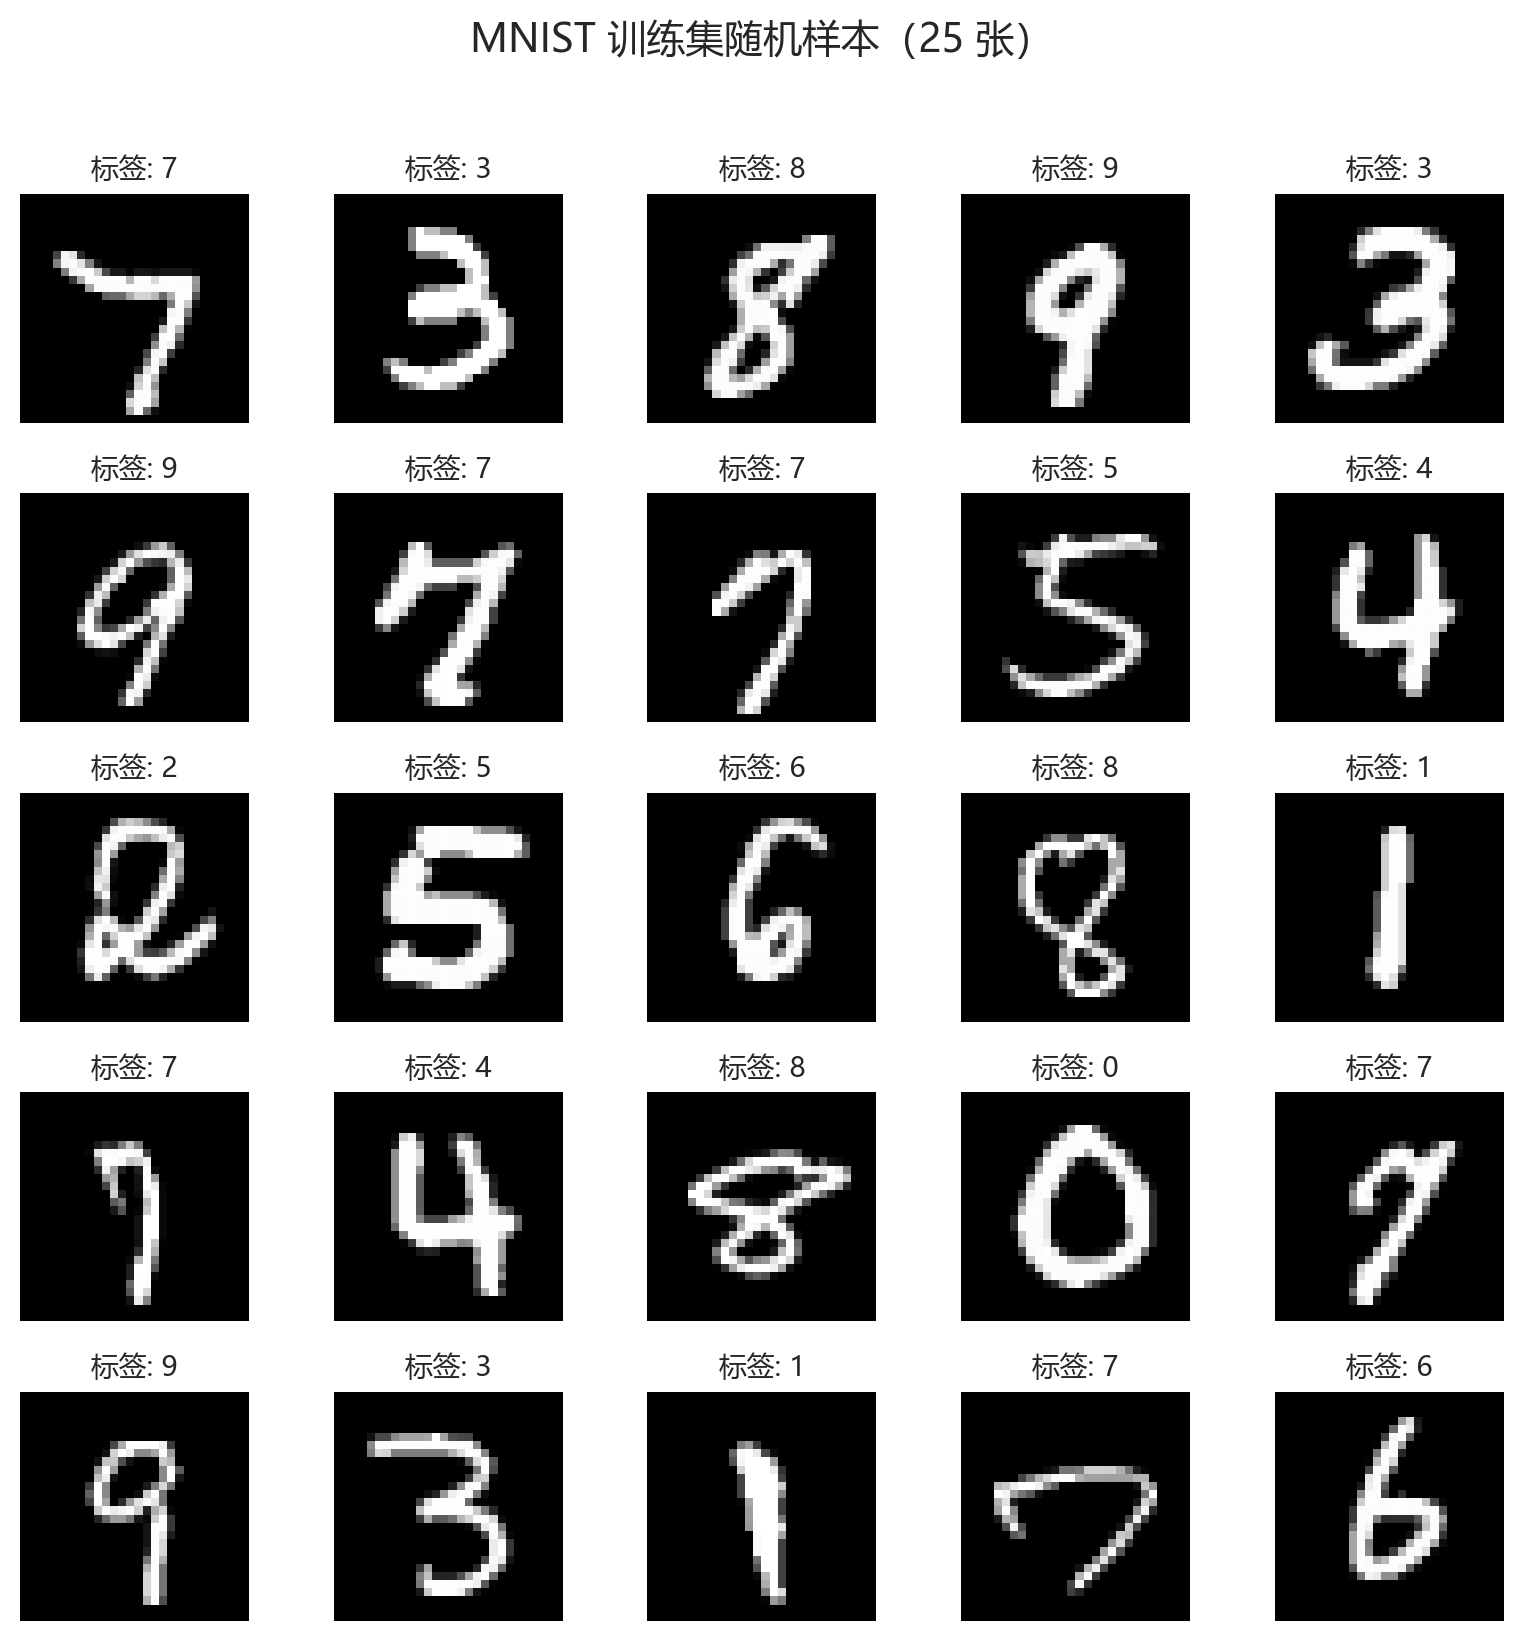

In [7]:
# [3. 样本可视化] 随机抽取 25 张图片 | 5×5 网格展示 | 标签标在每张图上
np.random.seed(42)
indices = np.random.choice(len(X_train), 25, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, idx in enumerate(indices):
    row, col = i // 5, i % 5
    axes[row, col].imshow(X_train[idx], cmap='gray')
    axes[row, col].set_title(f"标签: {y_train[idx]}", fontsize=10)
    axes[row, col].axis('off')

plt.suptitle('MNIST 训练集随机样本（25 张）', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. 类别分布分析

检查每个数字（0~9）的样本数量是否均衡。如果某些类别样本太少，模型可能学不好那一类。

> MNIST 各类别基本均衡，每类约 6000 张训练样本，这是一个「干净」的数据集。

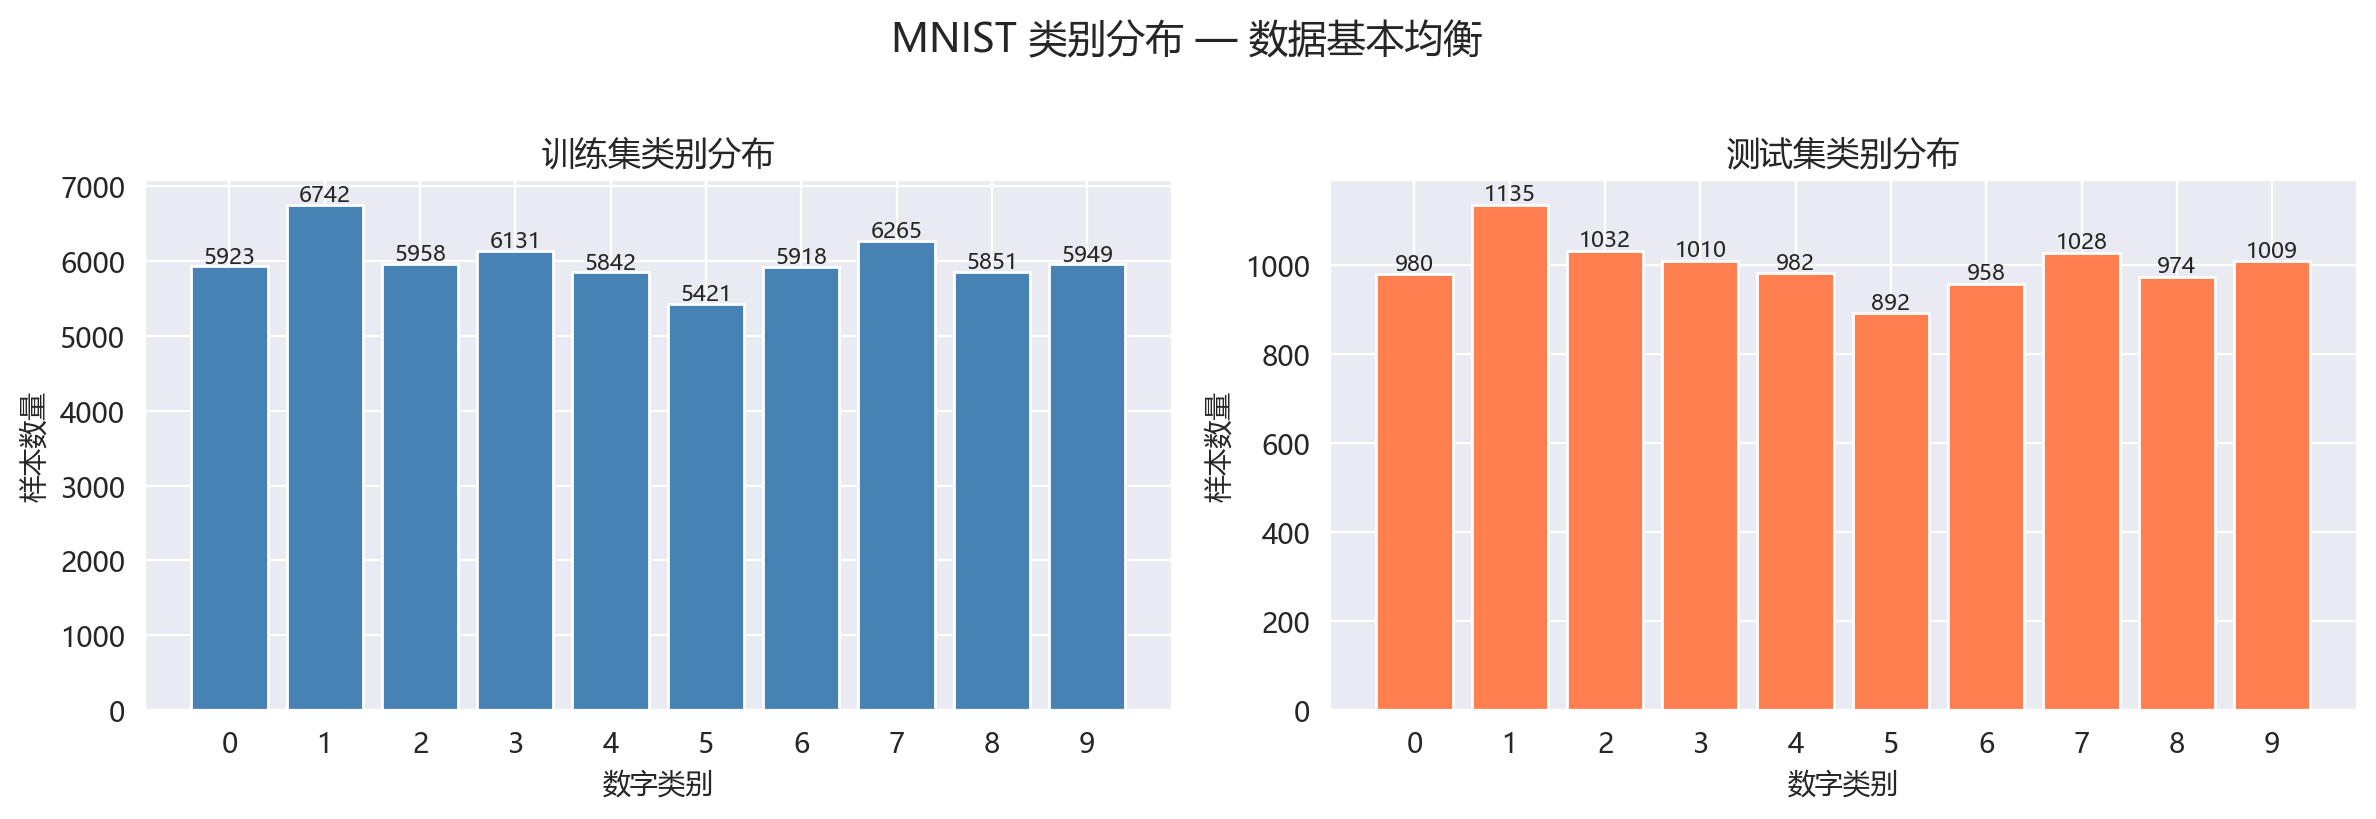

训练集: 共 60000 张, 每类约 6000 张
测试集: 共 10000 张, 每类约 1000 张


In [8]:
# [4. 类别分布] 柱状图展示 0~9 各类别样本数 | 检查数据是否均衡
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 训练集分布
unique_train, counts_train = np.unique(y_train, return_counts=True)
axes[0].bar(unique_train, counts_train, color='steelblue', edgecolor='white')
axes[0].set_xlabel('数字类别')
axes[0].set_ylabel('样本数量')
axes[0].set_title('训练集类别分布')
axes[0].set_xticks(range(10))
for i, c in enumerate(counts_train):
    axes[0].text(i, c + 50, str(c), ha='center', fontsize=8)

# 测试集分布
unique_test, counts_test = np.unique(y_test, return_counts=True)
axes[1].bar(unique_test, counts_test, color='coral', edgecolor='white')
axes[1].set_xlabel('数字类别')
axes[1].set_ylabel('样本数量')
axes[1].set_title('测试集类别分布')
axes[1].set_xticks(range(10))
for i, c in enumerate(counts_test):
    axes[1].text(i, c + 10, str(c), ha='center', fontsize=8)

plt.suptitle('MNIST 类别分布 — 数据基本均衡', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'训练集: 共 {len(y_train)} 张, 每类约 {len(y_train)//10} 张')
print(f'测试集: 共 {len(y_test)} 张, 每类约 {len(y_test)//10} 张')

## 5. 每个类别的样本展示

每个数字各取一张典型样本，感受各类别的视觉特征：
- **0**: 椭圆闭合，中间空心
- **1**: 一条竖线，可能带小勾
- **7**: 横线+斜线，与 1 容易混淆
- **4** 和 **9**: 上半部相似，模型容易搞混
- **3** 和 **8**: 都有弯曲结构

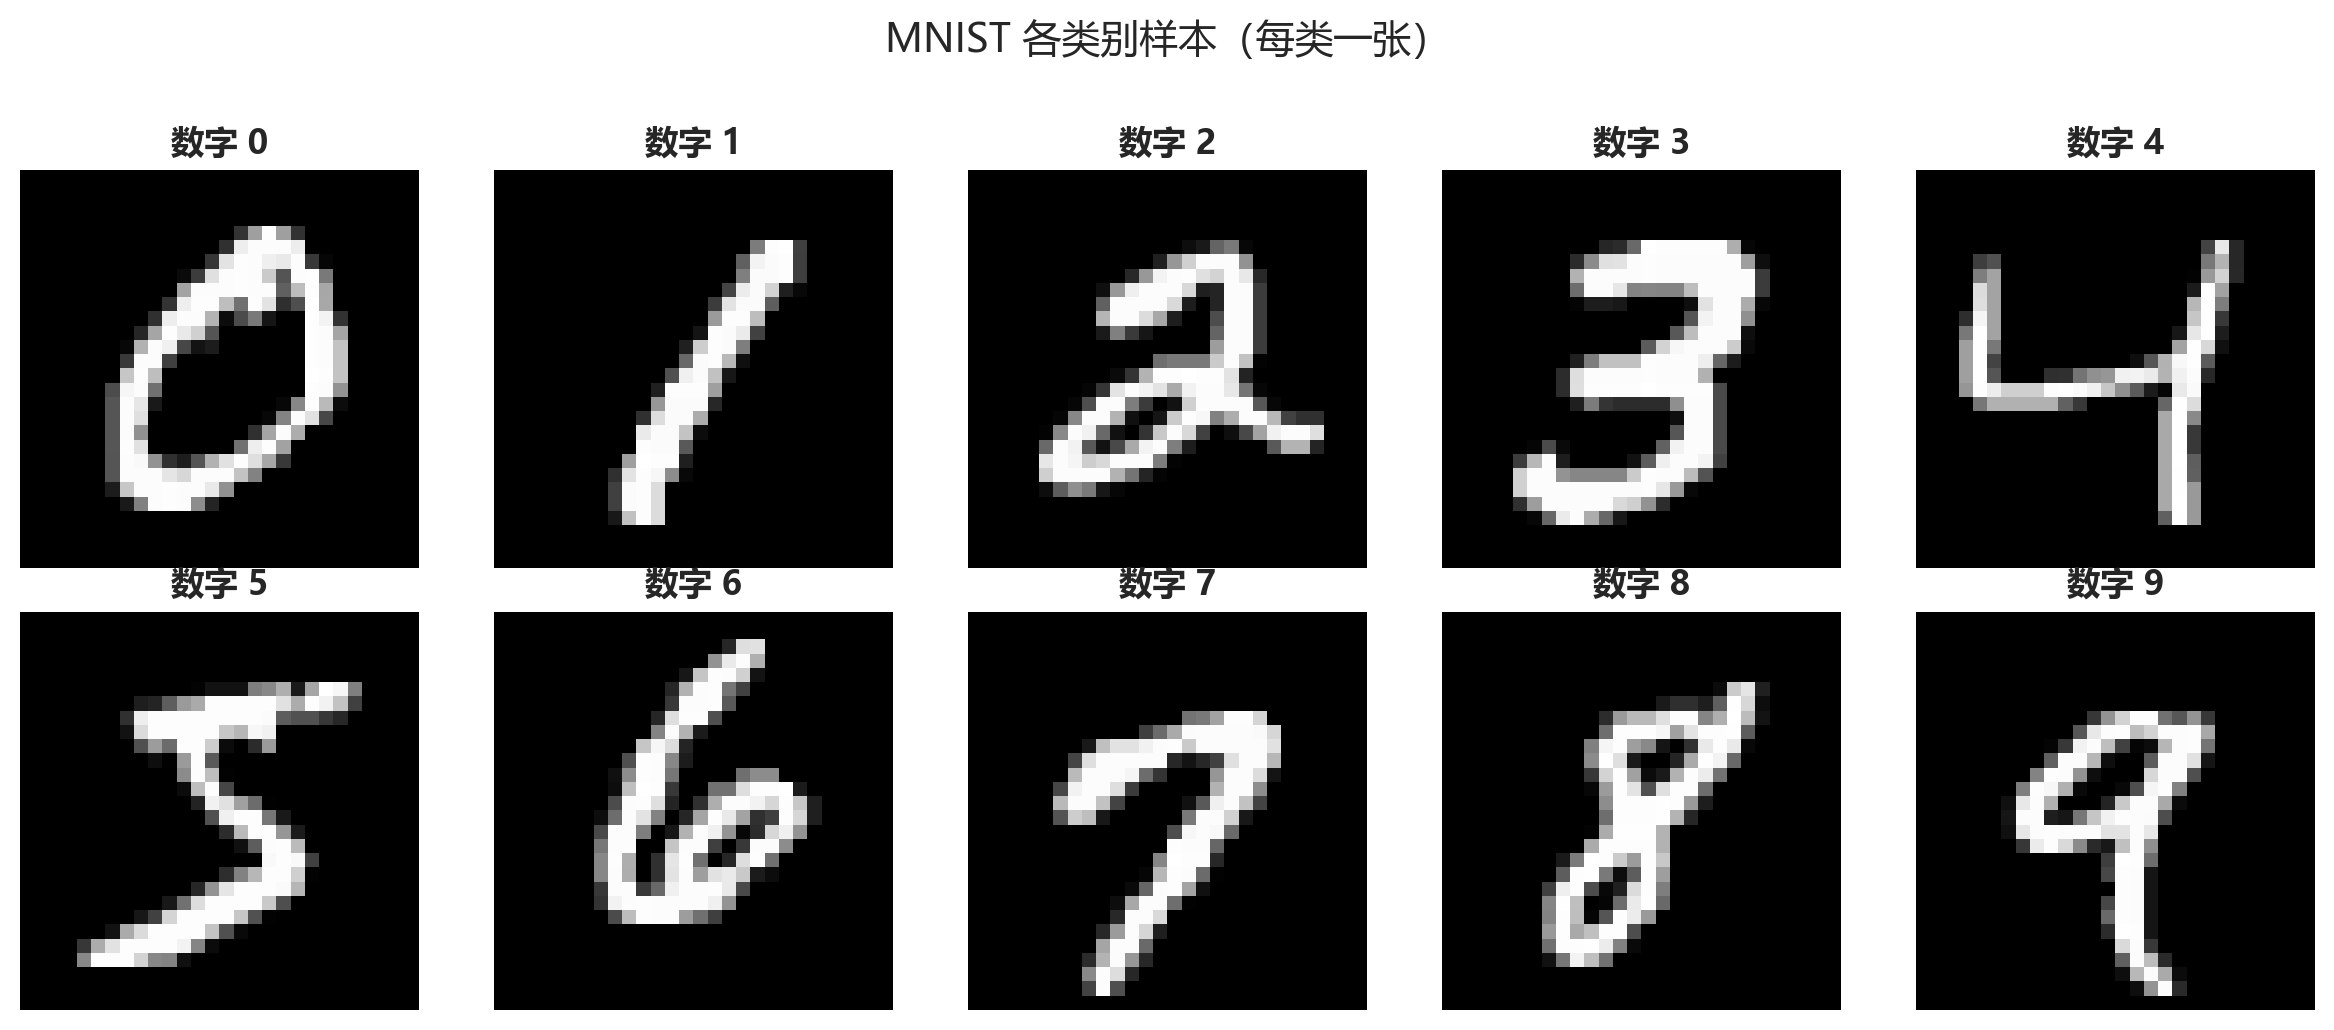

In [9]:
# [5. 各类别展示] 每个数字各取一张样本 | 2×5 网格 | 观察各类别视觉特征
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for digit in range(10):
    # 找第一个标签为 digit 的样本
    idx = np.where(y_train == digit)[0][0]
    axes[digit].imshow(X_train[idx], cmap='gray')
    axes[digit].set_title(f"数字 {digit}", fontsize=12, fontweight='bold')
    axes[digit].axis('off')

plt.suptitle('MNIST 各类别样本（每类一张）', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. 像素值分析

MNIST 是灰度图，像素值范围 0~255。大多数像素是 0（背景），只有数字笔画的像素非零。

### 为什么要归一化？

神经网络对输入尺度敏感。如果不归一化（像素 0~255），梯度会非常大，训练不稳定。
**除以 255 归一化到 [0, 1]** 是最简单有效的做法。

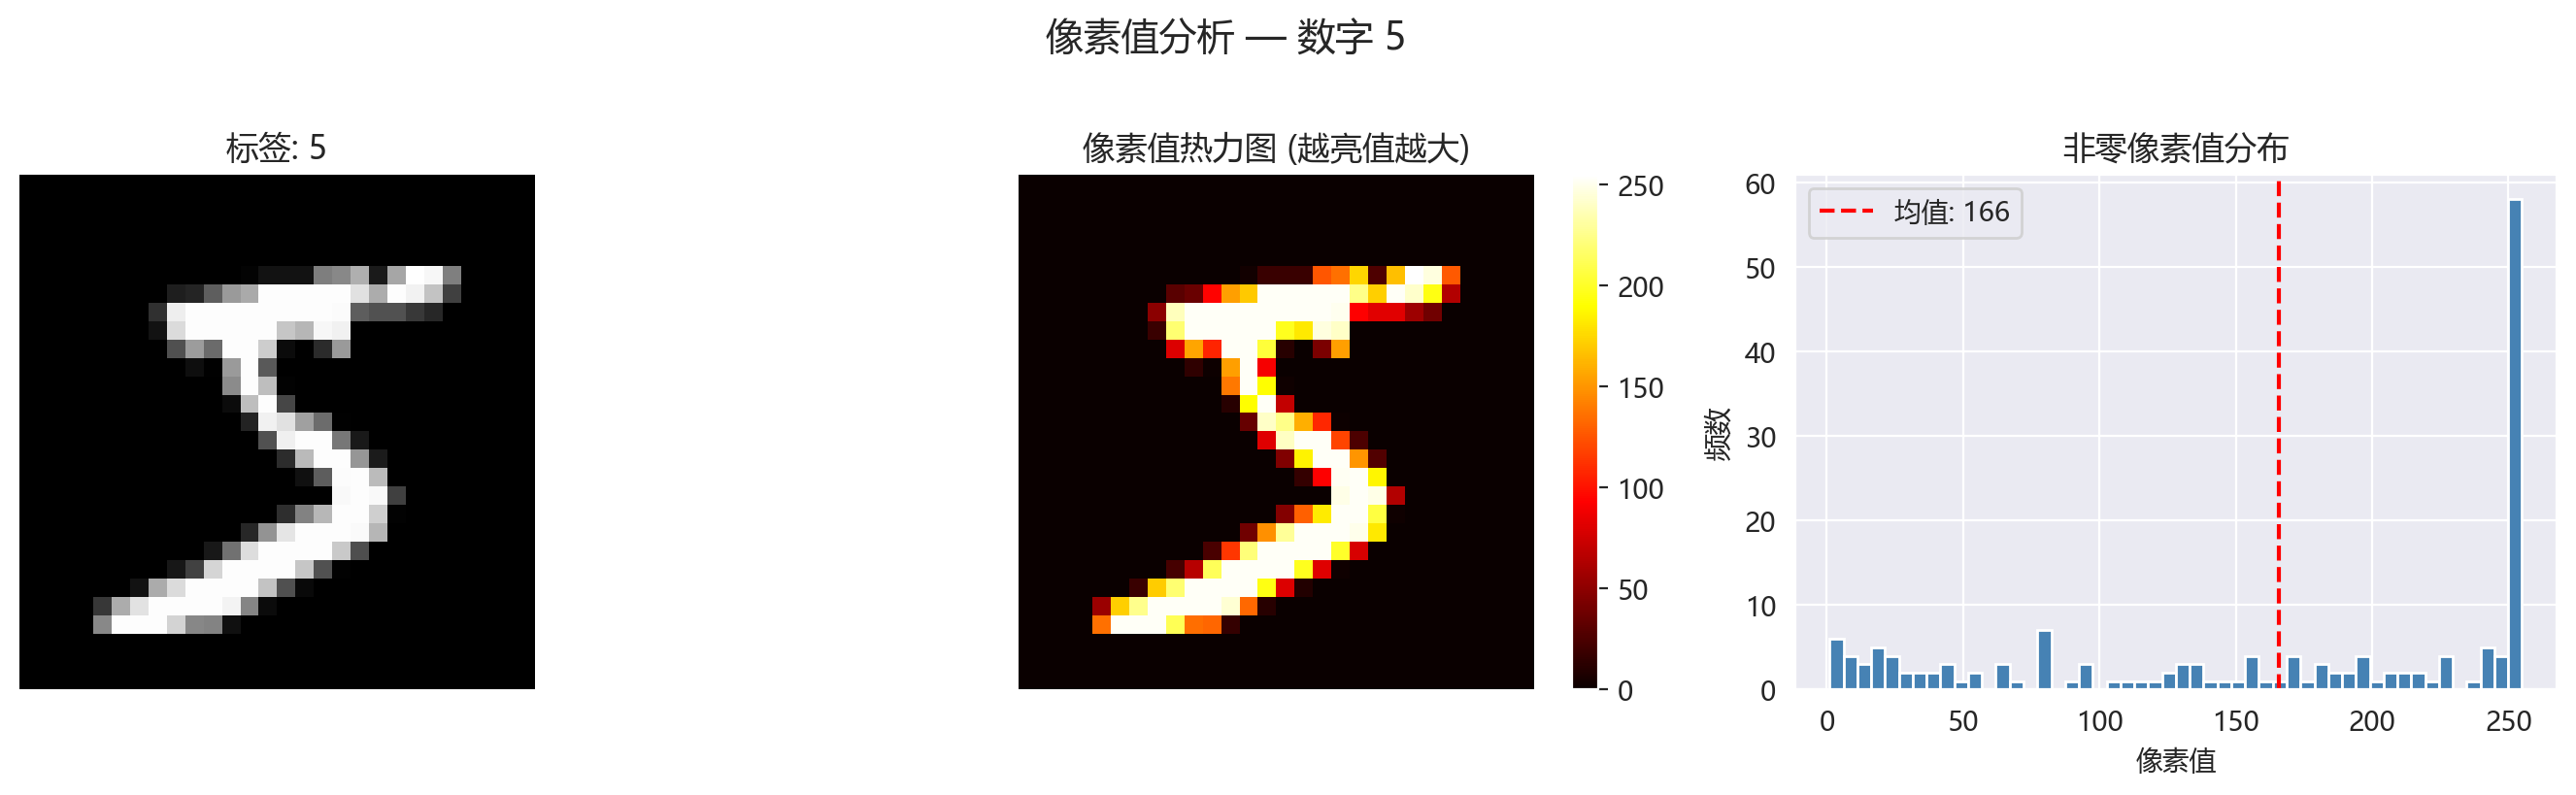

非零像素占比: 21.2% (大多数像素是背景)
非零像素均值: 165.8
非零像素范围: [1, 255]


In [10]:
# [6. 像素值分析] 查看一张图片的像素值分布 | 直方图展示非零像素
sample_idx = 0
sample = X_train[sample_idx]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 原图
axes[0].imshow(sample, cmap='gray')
axes[0].set_title(f"标签: {y_train[sample_idx]}")
axes[0].axis('off')

# 像素值热力图
im = axes[1].imshow(sample, cmap='hot', vmin=0, vmax=255)
axes[1].set_title('像素值热力图 (越亮值越大)')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046)

# 像素值直方图
flat_pixels = sample.flatten()
axes[2].hist(flat_pixels[flat_pixels > 0], bins=50, color='steelblue', edgecolor='white')
axes[2].set_xlabel('像素值')
axes[2].set_ylabel('频数')
axes[2].set_title('非零像素值分布')
axes[2].axvline(x=flat_pixels[flat_pixels > 0].mean(), color='red',
                linestyle='--', label=f'均值: {flat_pixels[flat_pixels>0].mean():.0f}')
axes[2].legend()

plt.suptitle(f'像素值分析 — 数字 {y_train[sample_idx]}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

nonzero_ratio = (sample > 0).mean()
print(f'非零像素占比: {nonzero_ratio:.1%} (大多数像素是背景)')
print(f'非零像素均值: {flat_pixels[flat_pixels > 0].mean():.1f}')
print(f'非零像素范围: [{flat_pixels[flat_pixels > 0].min()}, {flat_pixels[flat_pixels > 0].max()}]')

## 7. 转为 PyTorch Tensor 并构建 DataLoader

这是训练前的最后一步。根据模型类型，需要不同的输入格式：

| 模型 | 输入格式 | 说明 |
|------|----------|------|
| MLP | `(N, 784)` 展平向量 | 28×28 拉直为一维 |
| CNN / ResNet / ViT | `(N, 1, 28, 28)` 图像张量 | 保持二维结构 + 通道维 |
| LSTM | `(N, 28, 28)` 序列 | 28 行 = 28 个时间步 |

> 本 notebook 以 MLP 的展平格式为例。其他模型会在各自的 notebook 中准备对应格式。

In [11]:
# [7. 转 Tensor + DataLoader]
# numpy → torch.Tensor | 像素/255 归一化到 [0,1] | 展平 784 维 | DataLoader 自动分批+乱序
import torch
from torch.utils.data import TensorDataset, DataLoader

# 像素归一化到 [0,1]，展平为 784 维向量（MLP 的标准输入格式）
X_train_tensor = torch.tensor(
    X_train.reshape(-1, 28*28), dtype=torch.float32
) / 255.0
X_test_tensor = torch.tensor(
    X_test.reshape(-1, 28*28), dtype=torch.float32
) / 255.0

# 标签转为 LongTensor（CrossEntropyLoss 要求整数标签）
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.long)

# ======== 超参数集中修改区 ========
BATCH_SIZE = 64
# =================================

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor,  y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# 查看一个 batch 的数据
for images, labels in train_loader:
    print(f"Batch 图像形状: {images.shape}")   # (64, 784)
    print(f"Batch 标签形状: {labels.shape}")   # (64,)
    print(f"像素范围: [{images.min():.3f}, {images.max():.3f}]")
    print(f"标签示例: {labels[:10]}")
    print(f"\n训练集总批次数: {len(train_loader)}")
    print(f"测试集总批次数: {len(test_loader)}")
    break

Batch 图像形状: torch.Size([64, 784])
Batch 标签形状: torch.Size([64])
像素范围: [0.000, 1.000]
标签示例: tensor([2, 3, 8, 8, 3, 1, 1, 6, 3, 7])

训练集总批次数: 938
测试集总批次数: 157


## 8. 知识总结

| 概念 | 说明 |
|------|------|
| **数据归一化** | 像素值从 [0, 255] 除以 255 → [0, 1]，让训练更稳定 |
| **TensorDataset + DataLoader** | 将数据打包为 batch，支持打乱和自动加载 |

### 下一步

数据已准备就绪！进入 `02_mlp_training.ipynb` 开始训练你的第一个神经网络。